Outlier Detection, Handling and Imputation

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [56]:
data = {
    'department': ['HR', 'Tech', 'Tech', 'Finance', 'HR',
                   'Finance', 'Tech', 'HR', 'Finance', 'Tech'],
    'age':        [25, 32, 47, 51, 23, 38, 44, 29, None, 41],
    'salary':     [3200, 3400, 3100, 3600, 3300, 3250, 8500, 3150, 3400, None],
    'experience': [2, 5, 10, 15, 1, 7, None, 4, 6, 12],
    'score':      [88, 79, None, 91, 85, 76, 80, None, 83, 88]
}
df = pd.DataFrame(data)

In [57]:
q1, q3= np.nanpercentile(df['salary'], [25, 75])
iqr= stats.iqr(df['salary'], nan_policy= 'omit')

lower_fence=q1-(iqr*1.5)
upper_fence= q3+(iqr*1.5)

print(upper_fence, lower_fence)

outliers= df[(df['salary']<lower_fence) | (df['salary']>upper_fence)]
print(outliers)

3700.0 2900.0
  department   age  salary  experience  score
6       Tech  44.0  8500.0         NaN   80.0


In [61]:
df['salary_capped']= df['salary'].clip(lower= lower_fence, upper= upper_fence)
print(df.loc[df['salary']>upper_fence, ['salary', 'salary_capped']])

        salary  salary_capped
6  8500.000000         3700.0
9  3877.777778         3700.0


In [68]:
df['age']= df['age'].fillna(df['age'].median())
df['salary']= df['salary'].fillna(df['salary'].mean())
df['score']= df['score'].fillna(df['score'].median())
df['experience'] = df['experience'].fillna(df['experience'].median())
salary_log= np.log1p(df['salary_capped'])
df.isna().sum()



department       0
age              0
salary           0
experience       0
score            0
salary_capped    0
dtype: int64

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


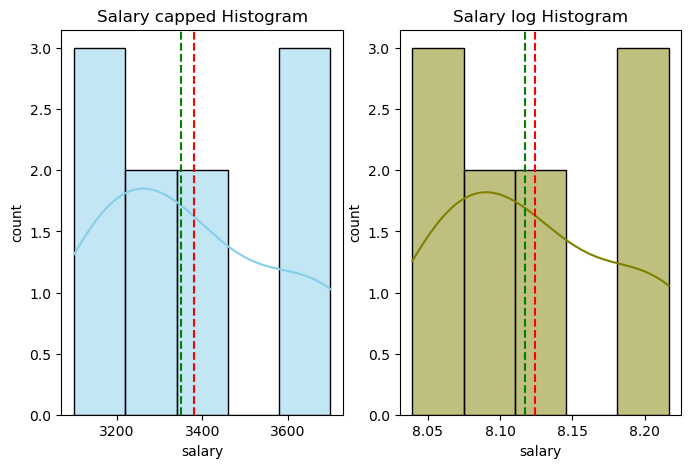

In [79]:
fig, (ax1, ax2)= plt.subplots(1, 2, figsize=(8,5))
sns.histplot(df['salary_capped'], ax= ax1, kde=True, color='skyblue' )
mean_capped= df['salary_capped'].mean()
median_capped= df['salary_capped'].median()
ax1.axvline(mean_capped, color='red', linestyle='--', label=f'mean:{mean_capped:.2f}')
ax1.axvline(median_capped, color='green', linestyle='--', label=f'median:{median_capped:.2f}')
sns.histplot(salary_log, ax= ax2, kde=True, color='olive')
mean_log= salary_log.mean()
median_log= salary_log.median()
ax2.axvline(mean_log, color= 'red', linestyle='--', label=f'mean:{mean_log:.2f}')
ax2.axvline(median_log, color= 'green', linestyle='--', label=f'median:{median_log:.2f}')
ax1.set(title='Salary capped Histogram', xlabel='salary', ylabel='count')
ax2.set(title= 'Salary log Histogram', xlabel='salary', ylabel='count')


plt.show()